In [1]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [50]:
def plotDistributions(means, vars):
    means     = means.flatten()
    variances = vars.flatten()
    x         = np.linspace(-100, 100, 100)
    stds      = np.sqrt(variances)
    print(stds)

    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    axes = axes.ravel()

    
    for i, (m, s) in enumerate(zip(means, stds)):
        y = 1/(s * np.sqrt(2*np.pi)) * np.exp(-0.5 * ((x - m) / s)**2)

        ax = axes[i]
        ax.plot(x, y)
        ax.set_title(f"Gaussian {i+1}\nMean={m:.2f}, Var={variances[i]:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("Density")

    plt.tight_layout()
    plt.show()

In [2]:
X_train = np.array([[1.2,2],[10.2,20],[43.2,40],[66.3,70]])
y_train = np.array([0,0,1,1])
X_test  = np.array([[53.4,58],[10.2,12],[40.7,50],[6.3,6]])
y_test  = np.array([0,0,1,1])

In [3]:
classes = np.unique(y_train)
n_classes = 2
n_samples, n_features = X_train.shape

In [ ]:
means_  = np.zeros((n_classes,n_features),dtype=np.float64)
vars_   = np.zeros((n_classes,n_features),dtype=np.float64)
priors_ = np.zeros(n_classes,   dtype=np.float64)

# print(means_)
# print(vars_)

[[0. 0.]
 [0. 0.]]
[[0. 0.]
 [0. 0.]]


In [ ]:
for idx,  c in enumerate(classes):
    X_c = X_train[y_train == c]
    means_[idx,:] = X_c.mean(axis=0)
    vars_[idx,:] = X_c.var(axis=0)
    priors_[idx] = X_train[y_train == idx].shape[0]
    

idx, c
0 0
idx, c
1 1


In [19]:
print(means_)
print(vars_)
print(priors_)

[[ 5.7  11.  ]
 [54.75 55.  ]]
[[ 20.25    81.    ]
 [133.4025 225.    ]]
[2. 2.]


In [46]:
def pdf2(idx, x):    
    _mean = means_[idx]
    _var = vars_[idx]
    numerator = np.exp(-((x - _mean) ** 2) / (2 * _var))
    denominator = np.sqrt(2 * np.pi * _var**2)
    return numerator / denominator

In [47]:
def pdf(idx,x):
    mean = means_[idx]
    var = vars_[idx]
    # print(mean)
    # print(var)
    # num = (np.exp((-0.5*(x-mean)/var)**2))
    # den = (var * np.sqrt(2* np.pi))
    # return num/den
    num = (np.exp(-((x-mean)**2)/(2*var**2)))
    den = (np.sqrt(2* np.pi *  var**2))
    return num/den
    

In [48]:
for x in X_test:
    posteriors = []
    posteriors2 = []
    for idx,c in enumerate(classes):
        prior = np.log(priors_[idx])
        # print(prior)
        # print(pdf(idx,x))
        posterior = np.sum(np.log(pdf(idx,x)))
        posterior = posterior + prior
        posteriors.append(posterior)
        posterior = np.sum(np.log(pdf2(idx,x)))
        posterior = posterior + prior
        posteriors2.append(posterior)
        
    

In [49]:
print(posteriors)
print(posteriors2)

[np.float64(-8.54967798892883), np.float64(-11.543866994339428)]
[np.float64(-8.710543710617596), np.float64(-25.58795202872731)]


[ 4.5   9.   11.55 15.  ]


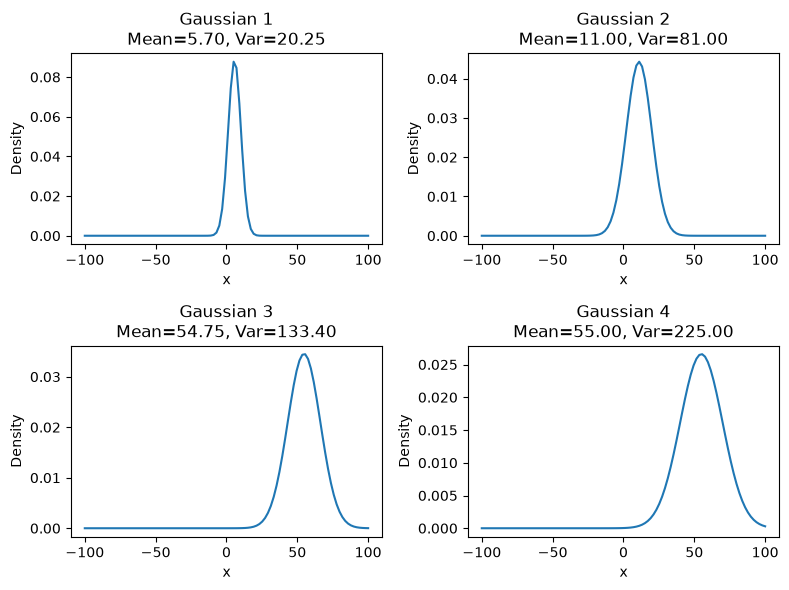

In [52]:
plotDistributions(means_, vars_)